# 待解决的问题：
1. 人类语言所使用的词汇在一些情况下是多义词，比如bank既可以指“银行”，也可以指“长椅”。传统的Word2Vec、GloVe预训练之后得到的词向量，和语境无关，**多义词只有一个词向量，没有办法区分同一个词的不同词义**；而现代模型（BERT）这类模型预训练之后得到的词向量，**同一个词在不同语境之下会得到不同的词向量**。为什么WordVec、GloVe预训练得到的词向量和语境无关？

# Word Embedding（Word2Vec）
词向量就是用于表示词的向量，也可以成为词的特征向量；将词映射到词向量的技术就成为“词嵌入”。

传统的NLP使用one-hot编码来表示词，它虽然简单，但是没办法准确表达词与词之间的相似性（对于任意两个词的one-hot表示，其余弦相似度都为0）。在此基础上，word2vec被提出解决上述问题，它将词映射到固定长度的实值向量，这些向量可以很好地表达相似度和不同词之间的关系。word2vec包含两种模型，skip-gram和COBOW。
## The Skip-Gram Model
Skip-gram模型假设一个词(center word)可以被用来生成它周围的词(context word)。其目标函数是在给定中心词的条件下生成其真实上下文的条件概率，并且由于假设的条件独立性，这个条件概率可以被处理为每个真实上下文的条件概率的乘积。在Word2Vec中，给定中心词生成上下文词的条件概率分布是通过“**中心词与上下文词的词向量内积的softmax**”来进行建模的。（Softmax函数将K维实数logit向量映射为合法的多分类概率分布）。

根据目标函数可以看出，skip-gram模型的参数实际上就是所有词分别作为中心词和上下文词时的词向量表示。在训练中，通过最大化目标函数（等于最小化负对数目标函数）使用随机梯度下降（这里进行随机采样的是窗口）更新模型参数。对于词典中的每个词，经过skip-gram模型的预训练，都会得到两个词向量（分别是其作为中心词和上下文词的词向量），在NLP应用中，通常将其作为中心词时得到的词向量当作该词的表示。
## The Continuous Bag of Words (CBOW) Model
CBOW假设在一个文本序列中，中心词是基于其上下文来生成的。其目标函数是在给定上下文的条件下生成真实的中心词的条件概率。这里条件概率的建模思路和skip-gram中的一样，特别需要指出的是，这里将上下文词总体的词向量表示为每个上下文词的词向量的平均值。同样，模型训练完成之后会得到所有词的两个词向量表示；与skip-gram不同的是，这里保留的是每个词作为上下文词时候的词向量表示。

总之，不管对于Skip-Gram还是CBOW，训练之后都会得到每个词的两个词向量表示，并且最终保留的都是作为生成者时的词向量表示，比如CBOW是通过上下文词生成中心词，最后保留的是每个词作为上下文词的词向量表示。
# Approximate Training
在skip-gram和CBOW中，我们都是通过softmax（词向量内积）来建模条件概率的：
* 对于Skip-Gram：它的目标函数中的$P(w_o|w_c)=\text{Softmax}(\bm{u}^T_o\bm{v}_c)$
* 对于CBOW：它的目标函数中的$P(w_c|W_o)=\text{Softmax}(\bm{u}^T_c\bar{\bm{v}}_o)$

而由于softmax的特点，以及我们通过取目标函数的负对数得到的损失函数的公式可以看到，它包含一个遍历全词典的求和项。随之而来的是**对损失函数求偏导之后，得到的梯度包含一个遍历全词典的求和项，这是一项巨大的计算成本**!为了降低计算复杂度，下面提供了两个近似训练的方法：negative sampling 和 hierarchical softmax，下面以skip-gram为例来说明这两种近似训练方法。
## Negative Sampling
Negative Sampling将skip-gram的目标函数中的多分类的离散条件概率分布修改为二分类条件概率分布。具体地，目标函数中的$p(w_o|w_c)$修改为$P(D=1|w_o,w_c)$,并记事件“D=1”为“上下文词$w_o$来自于中心词$w_c$的窗口”，并用$\sigma(\bm{u}^T_o\bm{v}_c)$来建模“D=1”的条件概率（Sigmoid函数将实数logit映射为[0,1]，作为二分类随机变量取正类的概率）

这里的一个关键点在于，如果不进行负采样的话，那么当中心词和上下文词的词向量是无穷大时，目标函数的值达到最大，然而这里学习到的词向量是无意义的；所以需要添加K个负采样样本来迫使模型学习到有效表示，且最后的梯度计算的复杂度是线性依赖于K的，不再包含遍历全词典的求和项了。
## Hierarchical Softmax
Hierarchical Softmax的思想是**将词典组织成一棵二叉树，每个目标词对应从根节点走到目标词叶节点的唯一路径。模型将预测目标词的过程，拆为路径上一系列二分类决策，每一步只需判断从当前节点应走向左子树还是右子树，最终联合概率就是每一步决策概率的乘积**。每一个内部节点对应一次二分类，使用Sigmoid函数来建模走向某一子树的概率。相比于原始Softmax需要遍历整个词典，复杂度为$O(|V|)$,Hierarchical Softmax只需沿着树的路径计算，复杂度降为$O(log_2(|V|))$，可以显著加速训练与推理。

# The Dataset for Pretraining Word Embeddings
目标：将原始的数据集处理为小批量样本迭代器\
token：这里将每一个word当作token


In [64]:
#from d2l import torch as d2l
import inspect
import os
import hashlib
import requests
import zipfile
import tarfile
import collections
import random
import math
import torch
import pickle

## 注册式管理数据集
通过**数据集注册表**统一管理数据集的下载链接和校验码，而不是硬编码链接——这样后续换数据集、维护数据集时，只需要修改注册表，无需改动读取逻辑，从而**解耦“数据集配置”和“数据处理逻辑”**。

如何获取校验码：
* 本地文件：通过在终端执行：certutil -hashfile 文件名.zip SHA1 进行获取（注意如果本地文件路径中有空格需要给整个路径加上双引号,否则命令行会把带多个空格的路径拆分成多个参数）;
* 远程文件：通常数据集官网会提供校验码，直接复制即可。

In [16]:
#数据集注册表:核心是字典结构，键为数据集名称，值为（下载链接+校验码）二元组
DATA_HUB = {
    "ptb":(
        #数据集下载链接（本地文件/远程URL都可以）
        'http://d2l-data.s3-accelerate.amazonaws.com/ptb.zip',
        #SHA-1校验码
        '319d85e578af0cdc590547f26231e4e31cdf1e42'
    )
}

## 数据集下载与解压
* 职责拆分：download只负责”下载+缓存+校验”，不涉及解压；download_extract只负责”调用下载+解压+返回路径“；**两个函数互不依赖核心逻辑，可单独调用**。
* 性能优化：先检查文件是否存在，如果存在就分块读取并验证校验码是否匹配，匹配则直接返回，避免重复下载（尤其是大数据集）；**分块读取**：对于大文件，一次性读取会直接内存溢出，分块读取是读取大文件的标准做法；**流式下载**：避免下载时占用过多内存，边下载边写入。**处理文件/网络下载请求时，必需考虑“大文件场景”。优先使用分块读取/流式下载，而非一次性处理。**
* 鲁棒设计：**格式校验**：提前预判不支持的解压格式，直接抛出明确错误，而非运行时崩溃；**校验码兜底**：下载后（或缓存命中时）必须校验SHA-1，确保文件未被篡改/下载完整（比如网络中断导致文件下载了一半，校验会失败）

In [22]:
#下载文件+缓存校验
def download(url, folder="./data", sha1_hash=None):
    """Download a file to folder and return the local filepath."""
    
    #设计兼容DATA_HUB,r如果传入的不是URL，而是DATA_HUB的Key，则从注册表中提取真实的URL和校验码
    if not url.startswith("http"):
        url, sha1_hash = DATA_HUB[url]
    
    #自动创建目录（不存在则创建，存在也不报错）
    os.makedirs(folder, exist_ok=True)

    #拼接目录路径和url中的文件名得到该文件的本地路径
    fname = os.path.join(folder, url.split("/")[-1])

    #缓存校验（如果文件已经存在且有校验码，就验证文件完整性）
    if os.path.exists(fname) and sha1_hash:
        sha1 = hashlib.sha1()
        with open(fname, "rb") as f:#r表示只读，b表示二进制模式，适用于非文本文件或者需要精准控制字节的文本文件
            #1MB分块读取（避免直接读取大文件造成内存溢出）
            while True:
                data = f.read(1048576)
                if not data:
                    break
                sha1.update(data)
        #如果校验通过：直接返回本地路径，无需重复下载
        if sha1.hexdigest() == sha1_hash:
            return fname
        
    #下载文件（如果校验失败/文件不存在时执行）
    print(f"Downloading {fname} from {url}...")
    #流式下载
    r = requests.get(url, stream=True, verify=True)
    with open(fname, "wb") as f:
        f.write(r.content)
    return fname            

In [18]:
#调用download下载文件+解压文件+路径返回
def download_extract(name, folder=None):
    """Download and extract a zip/tar file."""
    #调用download下载文件，得到文件的本地路径
    fname = download(name)

    #分别获取压缩文件所在目录（base_dir)、解压后的文件夹的目录data_dir)、压缩文件后缀（ext）
    base_dir = os.path.dirname(fname) # 如：../data
    data_dir, ext = os.path.splitext(fname) # data_dir=../data/ptb，ext=.zip

    #根据后缀选择解压方式
    if ext == ".zip":
        fp = zipfile.ZipFile(fname, "r") #处理zip文件
    elif ext in (".tar", ".gz"):
        fp = tarfile.open(fname, "r") #处理tar/tar.gz文件
    else:
        assert False, "Only zip/tar files can be extractef."#不支持的格式直接报错

    #解压到压缩文件所在目录，解压后文件会位于data_dir文件夹下面
    fp.extractall(base_dir)

    #返回解压文件夹的路径：如果制定了folder则拼接，否则返回解压文件夹的默认路径
    return os.path.join(base_dir, folder) if folder else data_dir

## 下载并读取PTB数据集的训练集并处理为token列表

In [23]:
def read_ptb():
    """Load the PTB dataset into a list of text lines."""
    #下载并解压PTB数据集，返回数据集所在的文件目录
    data_dir = download_extract("ptb")

    #读取训练集文件
    with open(os.path.join(data_dir, "ptb.train.txt")) as f:
        raw_text = f.read()
    
    #处理文本：按换行符切分每行，每行再按空格切分成单词列表
    return [line.split() for line in raw_text.split("\n")]
sentences = read_ptb()

In [24]:
len(sentences)

42069

## 词汇表类
将文本中的token和idx做双向映射，连接原始文本和模型的输入。

In [3]:
class Vocab:
    """Vocabulary for text."""
    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        #扁平化处理输入列表
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        
        #统计每个token的频数
        counter = collections.Counter(tokens)#返回一个字典，键是token，值是出现频数
        #按频数降序排序
        self.token_freqs = sorted(counter.items(), key=lambda x:x[1], reverse=True)

        #构建唯一token列表(raw_text中也包含<unk>,所以这里要把所有token都进行去重)
        #但是不能用set(),因为它只能无序去重，而dict.fromkey()可以实现有序去重，只保留第一次出现的位置
        self.idx_to_token = list(dict.fromkeys(["<unk>"] + reserved_tokens +[
            token for token, freq in self.token_freqs if freq >= min_freq
        ]))

        #构建token→idx的映射字典
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}
    #内置方法：简化调用
    def __len__(self):
        return len(self.idx_to_token)
    #查询方法：token→idx
    def __getitem__(self, tokens):
        # 处理单个token：存在则返回idx，否则返回<unk>的idx
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        #处理多个token（列表/元组）：递归调用，返回idx列表
        return [self.__getitem__(token) for token in tokens]
    #反向映射方法：idx→token
    def to_tokens(self, indices):
        #处理多个索引（只要有长度属性，例如列表、numpy数组、torch张量）：返回token列表
        if hasattr(indices, "__len__") and len(indices) > 1:
            return [self.idx_to_token[int(indice)] for indice in indices]
        #处理单个索引:返回单个token
        return self.idx_to_token[indices]
    #属性方法，便捷获取未知token索引:@property装饰器将方法转为属性，可直接用vocab.unk获取<unk>的索引
    @property
    def unk(self):
        return self.token_to_idx["<unk>"]

In [26]:
vocab = Vocab(sentences, min_freq=10)
len(vocab)

6719

In [27]:
vocab["<unk>"]

0

In [28]:
vocab.to_tokens(0)

'<unk>'

In [29]:
l = dict.fromkeys(["a", "b", "c", "c", "a"])
l, list(l.keys())

({'a': None, 'b': None, 'c': None}, ['a', 'b', 'c'])

## Subsampling 高频token + 构建corpus
原因是高频token类似于"the","a"等token会和各种token进行组合，但语义信息少，更多是语法使然，因此在进行词嵌入预训练的时候需要减少此类高频token出现的频率。

下采样通过“概率性丢弃高频词”，平衡词频分布，让模型更关注低频但有价值的词（如专业术语、核心名称）。

In [30]:
def subsample(sentences, vocab):
    """Subsample high-frequency words."""
    #先过滤未知词"<unk>",未知词本身无语义，所以不需要预训练词嵌入
    sentences = [[token for token in line if vocab[token] != vocab.unk] for line in sentences]
    #统计词频，返回字典：{token: 频数}
    counter = collections.Counter([token for line in sentences for token in line]) 
    num_tokens = sum(counter.values())

    #定义下采样判断函数
    def keep(token):
        return (random.uniform(0, 1) < math.sqrt(1e-4 / counter[token] * num_tokens))
    return ([[token for token in line if keep(token)] for line in sentences], counter)

In [31]:
subsampled, counter = subsample(sentences, vocab)

In [32]:
def compare_counts(token):
    return (f"# of '{token}':"
            f"before={sum([l.count(token) for l in sentences])}",
            f"after={sum([l.count(token) for l in subsampled])}")
compare_counts("the")

("# of 'the':before=50770", 'after=2031')

In [33]:
compare_counts("join")

("# of 'join':before=45", 'after=45')

In [34]:
#将下采样后的token列表映射到idx构建corpus
corpus = [vocab[line] for line in subsampled]
corpus[:3]

[[], [71, 2115, 406], [5277, 3054, 1580, 95]]

## 提取中心词和对应的上下文词
从语料库corpus中提取所有的中心词和其对应的上下文词，且窗口大小服从1到max_window_size的离散均匀分布。且对于每个中心词，我们将距离中心词不超过窗口大小的词当作上下文词。


In [35]:
def get_centers_and_contexts(corpus, max_window_size):
    """Returns center words and context words in skip-gram."""
    centers, contexts = [], []
    for line in corpus:
        #一个句子中至少有两个token，才能组成中心词-上下文词词对
        if len(line) < 2:
            continue
        centers += line
        #给每个中心词找到对应的上下文词
        for i in range(len(line)):
            window_size = random.randint(1, max_window_size)
            indices = list(range(max(0, i - window_size), 
                            min(len(line), i + window_size + 1)))
            #移除中心词
            indices.remove(i)
            contexts.append([line[index] for index in indices])
    return centers, contexts

In [37]:
tiny_dataset = [list(range(7)), list(range(7, 10))]
print("dataset", tiny_dataset)
for center, context in zip(*get_centers_and_contexts(tiny_dataset, 2)):
    print(f"center {center} has context {context}")

dataset [[0, 1, 2, 3, 4, 5, 6], [7, 8, 9]]
center 0 has context [1, 2]
center 1 has context [0, 2, 3]
center 2 has context [0, 1, 3, 4]
center 3 has context [2, 4]
center 4 has context [2, 3, 5, 6]
center 5 has context [3, 4, 6]
center 6 has context [5]
center 7 has context [8]
center 8 has context [7, 9]
center 9 has context [8]


In [38]:
#提取PTB数据集的所有中心词和上下文词,设置最大窗口为5
all_centers, all_contexts = get_centers_and_contexts(corpus, 5)

In [39]:
len(all_centers), len(all_contexts)

(343165, 343165)

## Negative Sampling
为了根据预定义的分布对噪声词进行采样，定义以下RandomGenerator类，实现了一个**带权重的随机采样器**，核心功能是：根据给定的采样权重（**相对权重，不用归一化**），从{1，2，..., n}（n为权重列表长度）中按权重概率随机抽取数字。且根据论文中的建议，噪声此的采样权重被设定为其在词典中的出现频数的0.75次方。

* 性能优化：**批量缓存采样结果**，随机采样时相对耗时的操作，如果random.choices()被高频调用（比如Word2Vec时每秒调用上万次）每次只生成1个结果会导致性能瓶颈；而一次生成10000个结果缓存起来，后续每次只需要读取缓存，就能减少大幅减少随机计算的次数，是工业级随机采样的典型实现。**学习：高频调用的随机函数，优先用“批量预生成+缓存”的方式提升性能。**



In [40]:
class RandomGenerator:
    """Randomly draw among {1,...,n} according to n sampling weights.
    随机采样器：支持批量缓存、减少random.choices频繁调用的开销。"""
    def __init__(self, sampling_weights):
        #初始化采样池[1, ..., n]
        self.populations = list(range(1, len(sampling_weights) + 1))
        #采样权重列表
        self.sampling_weights = sampling_weights
        #缓存的批量采样结果
        self.candidates = []
        #缓存结果的读取指针
        self.i = 0
    #缓存批量采样：如果缓存用完就一次性缓存k个采样结果，否则就读取之前缓存的结果
    def draw(self):
        #缓存用完/首次调用时，重新生成批量采样结果
        if self.i == len(self.candidates):
            #一次缓存k个随机样本
            self.candidates = random.choices(
                self.populations, self.sampling_weights, k=10000)
            #重置指针
            self.i = 0
        #读取缓存结果所以需要指针后移，指针为1，对应第一个缓存结果
        self.i += 1
        return self.candidates[self.i - 1]#返回指针对应的采样结果


In [41]:
def get_negatives(all_contexts, vocab, counter, K):
    """Return noise words in negative sampling."""
    #<unk>不参与噪声词，且其索引为0，所以采样池是[1, 2, ..., n]
    sampling_weights = [counter[vocab.to_tokens(i)]**0.75 for i in
                        range(1, len(vocab))]
    all_negatives, generator = [], RandomGenerator(sampling_weights)
    #给每个中心词生成对应的负样本
    for contexts in all_contexts:
        negatives = []
        #直到负样本的数量为正样本的K倍
        while len(negatives) < len(contexts) * K:
            neg = generator.draw()
            #排除正样本
            if neg not in contexts:
                negatives.append(neg)
        all_negatives.append(negatives)
    return all_negatives

In [42]:
all_negatives = get_negatives(all_contexts, vocab, counter, K=5)

In [43]:
len(all_negatives)

343165

上述代码**一次性生成并存储所有中心词的噪声词**，当数据集规模大、K值高时，会出现**内存溢出**，下面通过**惰性生成**

## 处理批量训练样本（中心词, 上下文词, 噪声词）为模型的输入格式
由于我们在对每个中心词选取上下文词的时候设置的窗口大小是一个随机数，而噪声词的数量又是上下文词数量的K倍，所以每个中心词所对应的上下文词+噪声词的总数可能不一样，为了加速计算，通常需要把上下文词+噪声词拼接在一起得到**contexts_negative**，但是长度不一样，所以这里通过补零使得中心词的拼接后的上下文词和噪声词的总数量相等；

相应地，为了避免这些填充的词影响损失的计算需要定义**掩码masks**，0代表是填充词，1代表非填充词；

除此之外，为了在context_negative中区分上下文词和噪声词，我们还需要一个**labels**来打标签，1代表是上下文词，0代表是噪声词。

下面的函数将一批（batch）零散的训练样本（中心词+上下文词+噪声词）做**长度对齐**，并生成掩码（masks）和标签（labels），最终输出可直接输入模型的张量格式。

In [44]:
def batchify(data):
    """Return a minibatch of examples for skip-gram with negative sampling."""
    max_len = max(len(c) + len(n) for _, c, n in data)
    centers, contexts_negatives, masks, labels = [], [], [], []
    for center, context, negative in data:
        cur_len = len(context) + len(negative)
        centers += [center]
        #拼接上下文词+噪声词，并用0填充到max_len
        contexts_negatives += [context + negative + [0] * (max_len - cur_len)]
        #掩码：padding位置标0，其他位置标1
        masks += [[1] * cur_len + [0] * (max_len - cur_len)]
        #标签：上下文词标1， 噪声词标0
        labels += [[1] * len(context) + [0] * (max_len - len(context))]
    #转换为张量并返回
    return (
        torch.tensor(centers).reshape(-1, 1), #中心词:(batch_size, 1)
        torch.tensor(contexts_negatives),   #上下文+噪声:(batch_size, max_len)
        torch.tensor(masks),                #掩码:(batch_size, max_len)
        torch.tensor(labels)                #标签：(batch_size, max_len)
    )

In [45]:
#例子
x_1 = (1, [2, 2], [3, 3, 3, 3, 3])
x_2 = (1, [2, 2, 2, 2], [3, 3])
batch = batchify([x_1, x_2])
batch

(tensor([[1],
         [1]]),
 tensor([[2, 2, 3, 3, 3, 3, 3],
         [2, 2, 2, 2, 3, 3, 0]]),
 tensor([[1, 1, 1, 1, 1, 1, 1],
         [1, 1, 1, 1, 1, 1, 0]]),
 tensor([[1, 1, 0, 0, 0, 0, 0],
         [1, 1, 1, 1, 0, 0, 0]]))

## 组合：从文本数据集到批量数据迭代器
* load_data_ptb():下载并预处理 PTB（Penn Treebank）文本数据集，最终生成可以直接用于训练词嵌入模型（如 Word2Vec）的 PyTorch 数据迭代器（DataLoader）。整个流程涵盖了从原始文本读取、词汇表构建、数据采样、样本生成到数据加载的全链路。
* 为什么需要自定义PTBDataset类：在 PyTorch 中，torch.utils.data.Dataset是所有自定义数据集类的基类，自定义PTBDataset的核心目的是**将分散的训练数据（中心词、上下文词、噪声词）封装成符合 PyTorch 数据加载规范的统一样本格式**，给DataLoader提供一个标准的样本容器，后续DataLoader就从这个数据容器中通过索引获取样本。
* 为什么需要自定义批量处理函数batchify：DataLoader()默认的批处理函数会按照位置把所有样本的对应元素聚合，相当于**增加一个样本维(batch_size, )，处理后数据符合模型的输入形状的要求**，但在这里不同样本中的上下文的长度是不一样的，强行聚合会报错（噪声也是一样的），所以需要自定义batchify。
* 为什么DataLoader需要通过参数num_workers开启多进程：没有开启多进程时，模型的批量数据的**加载过程与训练过程是串行的**：先由CPU加载第一批数据→GPU训练第一批数→CPU加载第二批数据→GPU训练第二批数据...;这样会使得GPU训练数据时CPU空闲；而CPU加载数据时GPU在等着要数据。开启了多进程之后，主进程CPU加载好第一批数据之后主进程用GPU训练当前批次，于此同时子进程1/2/3会提前加载后续批次的数据。从而让**CPU加载数据和GPU训练模型的耗时重叠**，缩短了整体的训练时间。

In [46]:
#下面的代码针对“DataLoader在使用多进程时python无法序列化定义在函数内部的本地类PTBDataset进行了修改”
#自定义Pytorch Dataset（需要覆盖__getitem__和__len__这两个方法）
class PTBDataset(torch.utils.data.Dataset):
    def __init__(self, centers, contexts, negatives):
        assert len(centers) == len(contexts) == len(negatives)
        self.centers = centers
        self.contexts = contexts
        self.negatives = negatives

    #按索引返回单个样本（中心词、上下文词、噪声词）
    def __getitem__(self, index):
        return (self.centers[index], self.contexts[index], 
                self.negatives[index])
    #返回批量大小
    def __len__(self):
        return len(self.centers)

def load_data_ptb(batch_size, max_window_size, num_noise_words):
    """Download the PTB dataset and load it to memory."""
    #多线程可提升数据读取效率
    num_workers = 4
    #读取PTB原始文本
    sentences = read_ptb()
    #构建词汇表
    vocab = Vocab(sentences, min_freq=10)
    #高频词下采样
    subsampled, counter = subsample(sentences, vocab)
    #将token列表转换为词汇表中的索引序列
    corpus = [vocab[line] for line in subsampled]
    #生成中心词和上下文词
    all_centers, all_contexts = get_centers_and_contexts(corpus, max_window_size)
    #生成噪声词
    all_negatives = get_negatives(all_contexts, vocab, counter, num_noise_words)

    #实例化自定义Dataset：将分散数据整理成一个标准的样本容器，
    #后续DataLoader只需要从这个容器里取样本即可。
    dataset = PTBDataset(all_centers, all_contexts, all_negatives)
    #构建DataLoader(自定义批处理函数batchify)
    data_iter = torch.utils.data.DataLoader(
        dataset, batch_size, shuffle=True, collate_fn = batchify, num_workers=0
    )
    return data_iter, vocab
    

In [47]:
data_iter, vocab = load_data_ptb(512, 5, 5)
names = ['centers', 'contexts_negatives', 'masks', 'labels']
for batch in data_iter:
    for name, data in zip(names, batch):
        print(name, "shape:", data.shape)
    break

centers shape: torch.Size([512, 1])
contexts_negatives shape: torch.Size([512, 60])
masks shape: torch.Size([512, 60])
labels shape: torch.Size([512, 60])


# Pretraining word2vec

In [48]:
import torch
from torch import nn
#from d2l import torch as d2l


### Embedding Layer
为什么嵌入层可以把token的索引映射成其特征向量？

其成因是嵌入层的归纳偏置，模型的归纳偏置是**模型被设计时自带的，不依赖数据的先验假设**——它决定了模型会“偏好”学习什么样的规律，也限制了模型的学习范围。

嵌入层的核心归纳偏置是：**每个离散的token索引，对应且仅对应一个固定的连续特征向量，仅通过查表映射**。正是因为这个偏置，嵌入层才会“直接取权重矩阵的第i行”作为tokeni的特征向量，训练过程只更新对应行，不改变映射方式；训练完成之后，权重矩阵自然演化成“语义查找表”。
### 前向传播
前向传播是神经网络从输入数据到输出预测值的完整计算流程：隐藏层对数据特征进行线性/非线性变换；输出层基于变换后的特征计算模型对任务目标的预测值。

Skip-Gram的任务目标是**给定中心词的条件下，预测其上下文词**，本质是模型通过**Softmax（中心词词向量与词汇表中所有词的词向量的内积）建模的条件概率分布**进行预测，但在实际训练中不会直接用全量Softmax（因为它需要遍历词汇表来计算，当词汇表很大的时候计算成本很高），而是用Negative_sampling进行近似计算，此时候选词只包括真实的上下文词和噪声词，并且此时我们用**Sigmoid（中心词词向量与上下文词+噪声词词向量的内积）来建模“候选词属于中心词的上下文词”的条件概率**。
1. 为什么skip-gram需要两个嵌入层（emb_v:中心词的嵌入层；emb_u:上下文词和噪声词的嵌入层）？
首先一个token作为预测者与作为被预测者时的语义是不同的，Skip-Gram是给定中心词预测上下文词，token作为预测者时的语义才是我们需要的，如果中心词与上下文词和噪声词共用一套参数，则无法区分“作为中心词的语义”和“作为上下文词的语义”。

2. 为什么Skip-Gram的前向传播的输出不进行Sigmoid变换？\
Sigmoid的作用是把得分映射到[0, 1]区间（表示“是正样本”的概率），但我们通常**在前向传播中只计算原始得分，把Sigmoid和损失计算合并到反向传播的过程中**，这样做更高效（减少了一次前向计算），也符合**Pytorch的“损失函数融合激活”的设计习惯**。


In [49]:
#centers:(batch_size, 1);contexts_negatives:(batch_size, max_len)
def skip_gram(centers, contexts_negatives, embed_v, embed_u):
    v = embed_v(centers)   #(batch_size, 1, num_features)
    u = embed_u(contexts_negatives) #(batch_size, max_len, num_features)
    pred = torch.bmm(v, u.permute(0, 2, 1))
    return pred #pred(batch_size, 1, max_len)

### Binary Cross-Entropy Loss
1. 为什么选择二项交叉熵损失作为Skip-Gram+Negative Sampling的损失函数？\
其实Skip-Gram+Negative Sampling的**目标函数的负对数似然与二项交叉熵损失二者在数学上是完全等价的**。\
对于单个二分类样本，它的真实标签$y \in \{0,1\}$,且预测$y=1$的概率为$p$，则该样本的二项交叉熵损失是：$$BCP(y,p)=-[y\log(p)+(1-y)\log(1-p)]$$
若该样本的真实标签为$y=1$，则$$BCP(1,p)=-\log(p)$$ 当p接近于1的时候，其损失接近于0；若该样本的真实标签为$y=0$，则$$BCP(0,p)=-\log(1-p)$$当p接近于0的时候，其损失接近于0。\
在Skip-Gram+Negative Sampling的目标函数中，Sigmoid(词向量内积)对应上述的预测为正类的概率，上下文词对应的标签是$y=1$，噪声词样本对应的标签是$y=0$，带入之后二者在数学上完全一样。

2. 为什么在计算二项交叉熵损失的时候需要对每个中心词求平均损失？
输入的形状是(batch_size, max_len)，每个位置对应一个二分类样本的二项交叉熵损失；使用weight=mask（mask是掩码矩阵，0标识构造Contexts_Negatives矩阵时padding的位置）屏蔽Padding无效位置之后，每个中心词的Window_size是1~max_window_size的随机整数，**导致不同中心词的总候选词数不同**，因此需要对每个中心词的有效损失求平均，来消除候选词数量不同带来的损失偏差，保证每个中心词的损失贡献公平。

3. Pytorch中为什么自定义的损失函数要继承nn.Module?\
继承nn.Module能让自定义损失函数**完全融入 PyTorch 的训练框架，获得模块化、设备兼容、梯度管理**等核心能力，而非单纯写一个函数。

In [50]:
# 二项交叉熵损失函数(融合激活函数)
class SigmoidBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
    #inputs=pred:(batch_size, max_len)
    #out:(batch_size, max_len)
    #outputs:(batch_size, )
    def forward(self, inputs, targets, mask=None):
        out = nn.functional.binary_cross_entropy_with_logits(
            inputs, targets, weight=mask, reduction="none")#警告：这里不能写成reduce="None",「reduction 是唯一合法的聚合控制参数，reduce 已废弃且类型受限」
        return out.mean(dim=1) #(batch_size, )
loss = SigmoidBCELoss()

### Initializing Model Parameters
1. 为什么这里对嵌入层权重的初始化选择Xavier初始化？\
因为Xavier通过控制权重的方差，使得神经网络中的线性层在前后向传播中的激活值与梯度都保持适当的方差。尤其适用于Sigmoid这种S型激活函数：因为它在0附近的近似线性，而在激活值比较大的地方梯度为0，容易引起梯度消失。\
在Skip-Gram中，有两个嵌入层（相当于线性变换层），且模型最终会通过**词向量内积+Sigmoid**计算损失，因此通过Xavier初始化可以约束初始激活值的规模，使其骡子啊Sigmoid梯度较大的区域，**有效缓解训练初期的梯度消失问题**。


In [51]:
#初始化模型参数：这里只需要初始化两个嵌入层的模型参数
embed_size = 100
net = nn.Sequential(
    nn.Embedding(num_embeddings=len(vocab),
                 embedding_dim=embed_size),
    nn.Embedding(num_embeddings=len(vocab),
                 embedding_dim=embed_size))
def init_weights(module):
    if type(module) == nn.Embedding:
        nn.init.xavier_uniform_(module.weight)
net.apply(init_weights) 

Sequential(
  (0): Embedding(6719, 100)
  (1): Embedding(6719, 100)
)

### Defining the Training Loop
* 为什么这里需要对“每个中心词的平均损失样本损失”进行修正？\
这里主要是解决不同中心词的有效候选词数量差异过大的问题，让损失计算更公平。
* 训练中Pytorch的设备执行逻辑：\
首先Python的原生逻辑（循环、打印、可视化、数值累加、优化器调用等等，都是在CPU执行，框架不会也无法移到GPU）；而张量的数值计算在哪个设备进行，基于张量本身所位于的设备：比如模型的前向传播需要计算模型参数与输入的矩阵运算，如果将模型和数据显式转移到GPU，那么其运算就自动在GPU执行。

In [53]:
import matplotlib.pyplot as plt
from IPython import display

try:
    # 在 Jupyter 中将图像显示为 SVG，更清晰
    from matplotlib_inline.backend_inline import set_matplotlib_formats
except ImportError:
    set_matplotlib_formats = None

def use_svg_display():
    """在 Jupyter 中使用 SVG 显示图像"""
    if set_matplotlib_formats is not None:
        set_matplotlib_formats('svg')

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置 matplotlib 的坐标轴属性"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

class Animator:
    """在训练过程中动态绘图"""

    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        if legend is None:
            legend = []

        use_svg_display()
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)

        # 保证 self.axes 总是可索引
        if nrows * ncols == 1:
            self.axes = [self.axes]

        self.config_axes = lambda: set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend
        )

        self.X = None
        self.Y = None
        self.fmts = fmts

    def add(self, x, y):
        """向图中添加多个数据点"""
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)

        if not hasattr(x, "__len__"):
            x = [x] * n

        if self.X is None:
            self.X = [[] for _ in range(n)]
        if self.Y is None:
            self.Y = [[] for _ in range(n)]

        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)

        self.axes[0].cla()
        for x_vals, y_vals, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x_vals, y_vals, fmt)

        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

In [54]:
class Accumulator:
    """For accumulating sums over `n` variables."""
    def __init__(self, n):
        """Defined in :numref:`sec_utils`"""
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [55]:
import time
class Timer:
    """Record multiple running times."""
    def __init__(self):
        """Defined in :numref:`sec_minibatch_sgd`"""
        self.times = []
        self.start()

    def start(self):
        """Start the timer."""
        self.tik = time.time()

    def stop(self):
        """Stop the timer and record the time in a list."""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """Return the average time."""
        return sum(self.times) / len(self.times)

    def sum(self):
        """Return the sum of time."""
        return sum(self.times)

    def cumsum(self):
        """Return the accumulated time."""
        return np.array(self.times).cumsum().tolist()


In [59]:
def train(net, data_iter, num_epoches, lr, device=None):
    #显式将模型转移到GPU（如果有的话）
    net = net.to(device)
    #初始化优化器
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    #初始化动画绘图器
    animator = Animator(xlabel="epoch", ylabel="loss",
                            xlim=[1, num_epoches])
    #初始化指标累加器：会随着批次增加累加各项指标的和
    metrics = Accumulator(2)#两个指标，一个是批次的总损失，一个是批次的总样本数

    for epoch in range(num_epoches):
        #timer记录每一个epoch的训练时间
        timer, num_batches = Timer(), len(data_iter)
        for i, batch in enumerate(data_iter):
            optimizer.zero_grad()
            centers, contexts_negatives, mask, label = [data.to(device) 
                                            for data in batch]
            pred = skip_gram(centers, contexts_negatives, net[0], net[1])
            pred = pred.reshape(mask.shape)
            l = loss(pred, label.float(), mask=mask) #/ mask.sum(axis=1) * mask.shape[1]
            l.sum().backward()
            optimizer.step()
            metrics.add(l.sum(), l.numel())
            if (i + 1) % (num_batches // 5) == 0 or i + 1 == num_batches:
                animator.add(epoch + (i+1)/num_batches, (metrics[0]/metrics[1],))
    #打印最终的全局总损失以及平均每个样本的训练时间
    print(f"loss{metrics[0] / metrics[1]:.3f}, "
          f"{metrics[1] / timer.stop():.1f} token/sec on {str(device)}")

loss0.125, 741673.8 token/sec on None


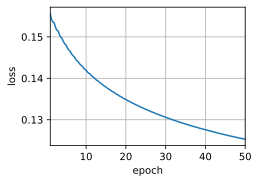

In [63]:
num_epoches, lr = 50, 0.002
train(net, data_iter, num_epoches, lr)

### Applying Word Embeddings
下面这段代码**基于训练好的词嵌入查找某个token的相似词**，本质是通过**余弦相似度**计算目标词与词典中所有词的语义相似度，最终会返回最相似的K个词。

In [65]:
def get_similar_tokens(query_token, k, embed):
    #提取训练好的嵌入层的训练权重
    W = embed.weight.data
    #获取目标词的词向量
    x = W[vocab[query_token]]
    #计算目标词与词典中所有词的余弦相似度, +1e-9是数值稳定性处理
    cos = torch.mv(W, x) / torch.sqrt(torch.sum(W * W, dim=1) * torch.sum(x * x + 1e-9))
    #获取与目标词相似度前K的词的索引,K+1是因为目标词与它本身的相似度最高
    topk = torch.topk(cos, k+1)
    #[1]获取相似度前k的词的索引 
    indices = topk[1].cpu().numpy().astype("int32")
    print(f"The top {k} tokens:{vocab.to_tokens(indices)[1:]}")

    # for i in indices[1:]:
    #     print(f"cosine similar={cos[i]:.3f}:{vocab.to_tokens(i)}")

get_similar_tokens("chip", 3, net[0])

The top 3 tokens:['intel', 'chips', 'attractive']


## 保存词嵌入向量和词汇表实例

In [66]:
save_obj = {
    "vocab": vocab,            # 类实例
    "embedding": net[0].weight.data   # 嵌入向量
}
with open("vocab_and_embedding.pkl", "wb") as f:
    pickle.dump(save_obj, f)

# UMAP可视化词嵌入向量

## 加载保存的词嵌入模型权重和词汇表

In [7]:
import pickle

with open("vocab_and_embedding.pkl", "rb") as f:
    load_obj = pickle.load(f)

vocab = load_obj["vocab"]          # 词汇表类实例
embeddings = load_obj["embedding"]  # 词嵌入向量

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import umap

def reduce_embeddings_umap(embeddings, n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42):
    """
    使用 UMAP 将高维词向量降到二维
    """
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state
    )
    embeddings_2d = reducer.fit_transform(embeddings)
    return embeddings_2d

def plot_umap_embeddings(
    embeddings_2d,
    tokens,
    figsize=(8, 8),
    point_size=8,
    alpha=0.7,
    annotate_tokens=None,
    annotate_indices=None,
    annotate_every=None,
    title='UMAP Visualization of Word Embeddings',
    save_path=None
):
    """
    绘制 UMAP 降维后的词向量

    参数说明：
    - embeddings_2d: UMAP 输出的二维坐标，shape=[vocab_size, 2]
    - tokens: 与索引对应的 token 列表
    - annotate_tokens: 需要特别标注的 token 列表，例如 ['china', 'king']
    - annotate_indices: 需要特别标注的索引列表
    - annotate_every: 每隔多少个点标一个标签，例如 100 表示每 100 个词标一次
    - save_path: 图片保存路径，例如 'umap_words.png'
    """
    plt.figure(figsize=figsize)

    x = embeddings_2d[:, 0]
    y = embeddings_2d[:, 1]

    # 绘制全部点
    plt.scatter(x, y, s=point_size, alpha=alpha, c='steelblue')
    plt.title(title, fontsize=16)
    plt.xlabel('UMAP-1')
    plt.ylabel('UMAP-2')
    plt.grid(True, linestyle='--', alpha=0.3)

    # 需要标注的索引集合
    indices_to_annotate = set()

    if annotate_indices is not None:
        indices_to_annotate.update(
            idx for idx in annotate_indices if 0 <= idx < len(tokens)
        )

    if annotate_tokens is not None:
        token_to_idx = {tok: i for i, tok in enumerate(tokens)}
        for tok in annotate_tokens:
            if tok in token_to_idx:
                indices_to_annotate.add(token_to_idx[tok])

    if annotate_every is not None and annotate_every > 0:
        indices_to_annotate.update(range(0, len(tokens), annotate_every))

    # 加标签
    for idx in indices_to_annotate:
        plt.annotate(
            tokens[idx],
            (x[idx], y[idx]),
            fontsize=8,
            alpha=0.85
        )

    # 对高亮点重新画一遍，颜色更醒目
    if len(indices_to_annotate) > 0:
        highlight_x = [x[idx] for idx in indices_to_annotate]
        highlight_y = [y[idx] for idx in indices_to_annotate]
        plt.scatter(highlight_x, highlight_y, s=20, c='red', alpha=0.9)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()



## 可视化

词向量矩阵形状: (100, 100)
词表大小: 100


d:\DP_NLP_course\nlp_course\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


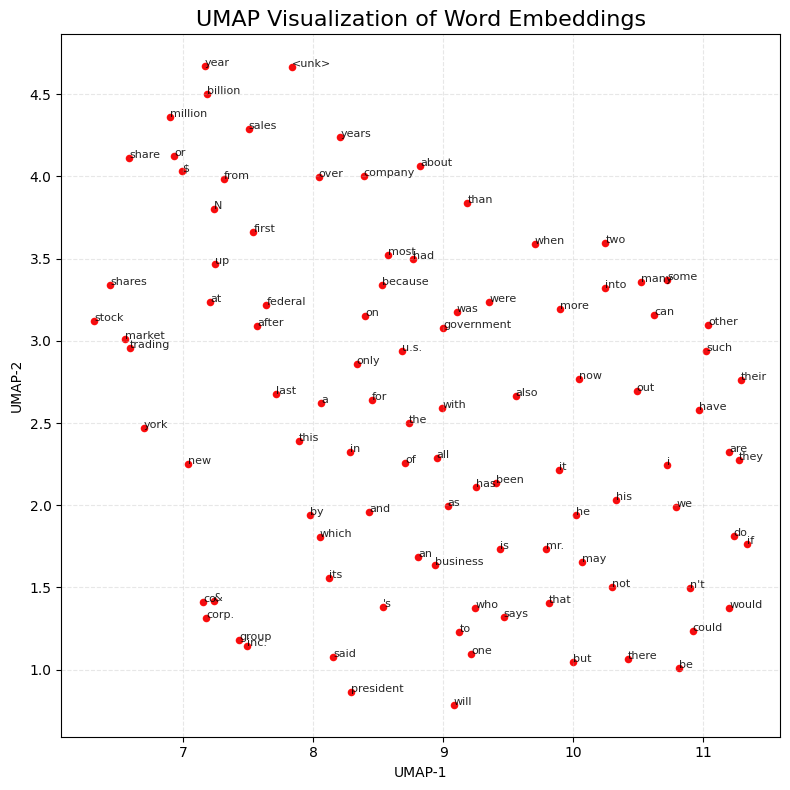

In [14]:
#获取前500个词嵌入向量和对应的token
embeddings = embeddings[:100]
if isinstance(embeddings, torch.Tensor):
    embeddings = embeddings.detach().cpu().numpy()
vocab_size = embeddings.shape[0]
tokens = vocab.to_tokens(list(range(vocab_size)))

print(f'词向量矩阵形状: {embeddings.shape}')
print(f'词表大小: {len(tokens)}')
#UMAP降维
embeddings_2d = reduce_embeddings_umap(embeddings)
#绘图，设置需要标注token的索引或者间隔
plot_umap_embeddings(embeddings_2d=embeddings_2d,tokens=tokens,annotate_every=True, 
                     save_path="./word_embeddings_umap.png")